In [1]:
from google.colab import files
uploaded = files.upload()      # choose best.pt from your computer

Saving best (1).pt to best (1).pt


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.3 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/test_img.jpg: 512x448 1 Transverse Displaced, 324.4ms
Speed: 19.8ms preprocess, 324.4ms inference, 30.2ms postprocess per image at shape (1, 3, 512, 448)
Results saved to /content/runs/detect/predict
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([8.])
conf: tensor([0.6589])
data: tensor([[4.4257e+02, 7.3120e+02, 5.6243e+02, 8.1061e+02, 6.5889e-01, 8.0000e+00]])
id: None
is_track: False
orig_shape: (1024, 840)
shape: torch.Size([1, 6])
xywh: tensor([[502.5009, 770.9041, 119.8596,  79.4028]])
xywhn: tensor([[0.5982, 0.7528, 0.1427, 0.0775]])
xyxy: tensor([[442.5710, 731.2026, 562.4307, 810.6055]])
xyxyn: tensor([[0.5269, 0.7141, 0.6696, 0.

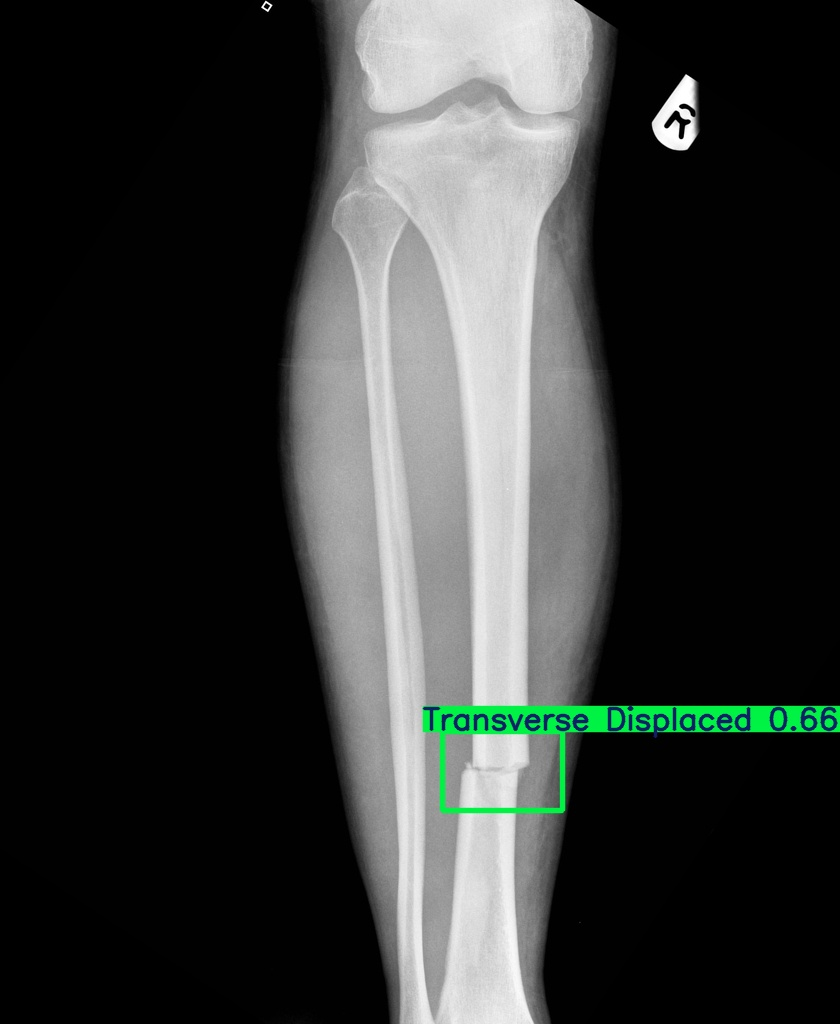

In [3]:
from ultralytics import YOLO

model = YOLO("/content/best (1).pt")   # loads your uploaded weights

# Test on a Google image URL
import requests
from IPython.display import Image, display

def predict_from_url(url, filename="test_img.jpg"):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers)
    with open(filename, "wb") as f:
        f.write(r.content)

    results = model.predict(source=filename, conf=0.25, save=True)
    print(results[0].boxes)     # optional: print raw detection info
    display(Image(filename=results[0].save_dir + f"/{filename}"))

# Example test
predict_from_url(
  "https://prod-images-static.radiopaedia.org/images/23617231/c55affc44debce6bd6a47407e4fb55_jumbo.jpeg"
)


image 1/1 /content/test_img.jpg: 512x352 1 Healthy, 106.7ms
Speed: 2.4ms preprocess, 106.7ms inference, 1.1ms postprocess per image at shape (1, 3, 512, 352)
Results saved to /content/runs/detect/predict2
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([2.])
conf: tensor([0.5799])
data: tensor([[ 26.0434,  38.6573, 161.3747, 260.1033,   0.5799,   2.0000]])
id: None
is_track: False
orig_shape: (277, 182)
shape: torch.Size([1, 6])
xywh: tensor([[ 93.7090, 149.3803, 135.3313, 221.4460]])
xywhn: tensor([[0.5149, 0.5393, 0.7436, 0.7994]])
xyxy: tensor([[ 26.0434,  38.6573, 161.3747, 260.1033]])
xyxyn: tensor([[0.1431, 0.1396, 0.8867, 0.9390]])


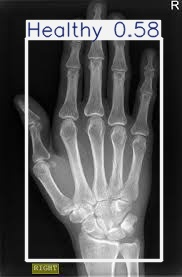

In [4]:
from ultralytics import YOLO

model = YOLO("/content/best (1).pt")   # loads your uploaded weights

# Test on a Google image URL
import requests
from IPython.display import Image, display

def predict_from_url(url, filename="test_img.jpg"):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers)
    with open(filename, "wb") as f:
        f.write(r.content)

    results = model.predict(source=filename, conf=0.25, save=True)
    print(results[0].boxes)     # optional: print raw detection info
    display(Image(filename=results[0].save_dir + f"/{filename}"))

# Example test
predict_from_url(
  "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTpGK0_meTjApHj8j3DmVY0bxqEAqESk86EJQ&s"
)

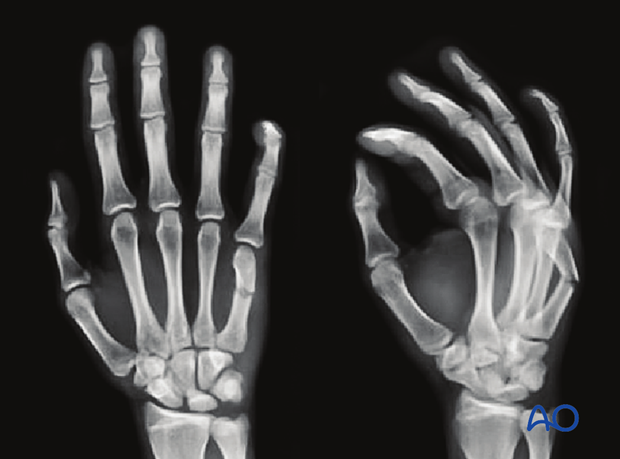


Top-3 Predicted Fracture Types:
1. Oblique Displaced | Confidence: 0.85
2. Comminuted | Confidence: 0.13
3. Transverse | Confidence: 0.01


In [15]:
# ================================
#  CNN Fracture Detector – One Cell
# ================================

import torch, torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import requests
from io import BytesIO
from IPython.display import display
from google.colab import files

# ---- 1. Define class names (must match training dataset order)
class_names = [
    'Comminuted',
    'Greenstick',
    'Healthy',
    'Linear',
    'Oblique Displaced',
    'Oblique',
    'Segmental',
    'Spiral',
    'Transverse Displaced',
    'Transverse'
]

# ---- 2. Load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)

state_dict = torch.load("/content/cnn_fracture_model (1).pth", map_location=device)
model.load_state_dict(state_dict)
model = model.to(device).eval()

# ---- 3. Pre-processing
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# ---- 4. Predict from an online image (Top-3 predictions)
def predict_from_url(url):
    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    img = Image.open(BytesIO(r.content)).convert("RGB")
    display(img)                                     # show test image
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)[0]   # shape: [10]

    # Top-3 predictions
    top3 = torch.topk(probs, 3)
    indices = top3.indices.cpu().numpy()
    scores = top3.values.cpu().numpy()

    print("\nTop-3 Predicted Fracture Types:")
    for i, (idx, score) in enumerate(zip(indices, scores)):
        print(f"{i+1}. {class_names[idx]} | Confidence: {score:.2f}")

# ---- 5. Test on a sample image
predict_from_url(
  "https://media.aofoundation.org/-/jssmedia/surgery/77/77_d210_i020.png?w=620"
)